Path to dataset files: /kaggle/input/customer-segmentation-tutorial-in-python
First 5 rows of dataset:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-nul

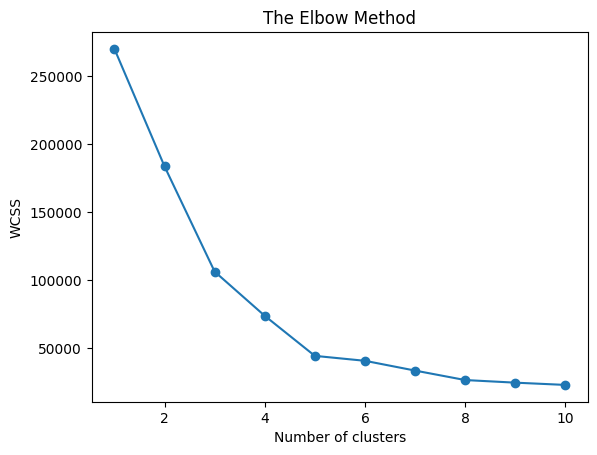

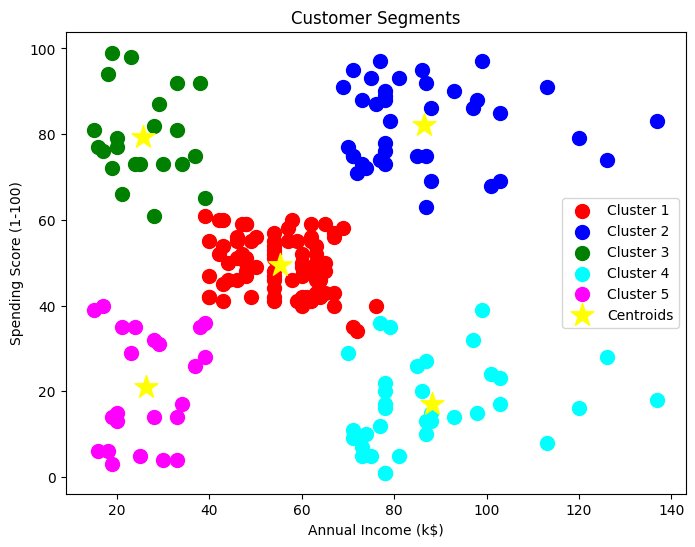

In [3]:
# Task 2 - Prodigy Infotech ML Internship
# K-Means Clustering on Customer Purchase History

# Step 1: Install kagglehub if not already installed
!pip install kagglehub --quiet

# Step 2: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

import kagglehub

# Step 3: Download Dataset from Kaggle using kagglehub
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")
print("Path to dataset files:", path)

# Step 4: Load CSV (the dataset contains "Mall_Customers.csv")
data = pd.read_csv(path + "/Mall_Customers.csv")

# Step 5: Explore Dataset
print("First 5 rows of dataset:")
print(data.head())
print("\nDataset Info:")
print(data.info())

# Step 6: Select Features (Annual Income & Spending Score)
X = data.iloc[:, [3, 4]].values   # column index 3 = Annual Income, 4 = Spending Score

# Step 7: Elbow Method to Find Optimal Clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# Step 8: Train KMeans with Optimal K (let’s assume 5 clusters from elbow curve)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Step 9: Visualize the Clusters
plt.figure(figsize=(8,6))
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s=100, c='green', label='Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s=100, c='cyan', label='Cluster 4')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s=100, c='magenta', label='Cluster 5')

# Plot centroids
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            s=300, c='yellow', marker='*', label='Centroids')

plt.title('Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()


In [4]:
# Add cluster labels to dataset
data['Cluster'] = y_kmeans

# View first 10 with cluster labels
print(data.head(10))


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   
5           6  Female   22                  17                      76   
6           7  Female   35                  18                       6   
7           8  Female   23                  18                      94   
8           9    Male   64                  19                       3   
9          10  Female   30                  19                      72   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  
5        2  
6        4  
7        2  
8        4  
9        2  


In [5]:
# Cluster analysis
cluster_summary = data.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
print("\nCluster Summary (Average values):")
print(cluster_summary)



Cluster Summary (Average values):
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


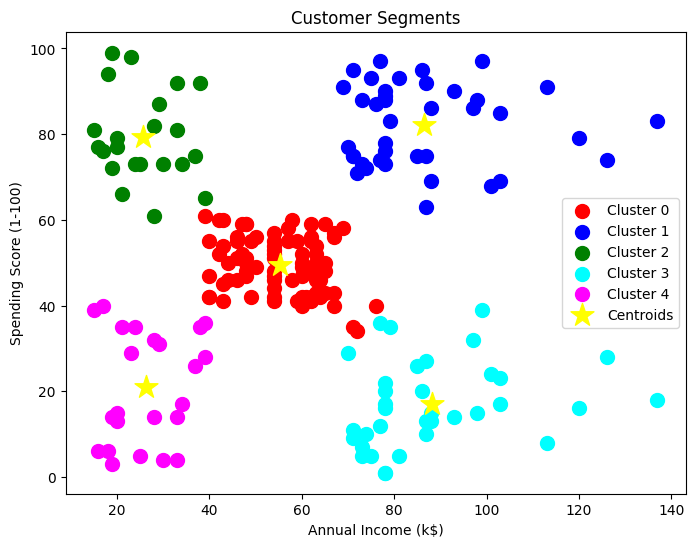

In [6]:
# Better visualization with cluster centers and labels
plt.figure(figsize=(8,6))

colors = ['red', 'blue', 'green', 'cyan', 'magenta']
for i in range(5):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1],
                s=100, c=colors[i], label=f'Cluster {i}')

# Plot centroids
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            s=300, c='yellow', marker='*', label='Centroids')

plt.title('Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()


   Cluster  Annual Income (k$)  Spending Score (1-100)
0        0           55.296296               49.518519
1        1           86.538462               82.128205
2        2           25.727273               79.363636
3        3           88.200000               17.114286
4        4           26.304348               20.913043


/tmp/ipython-input-1219658804.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cluster', y='Annual Income (k$)', data=cluster_summary, palette="viridis")


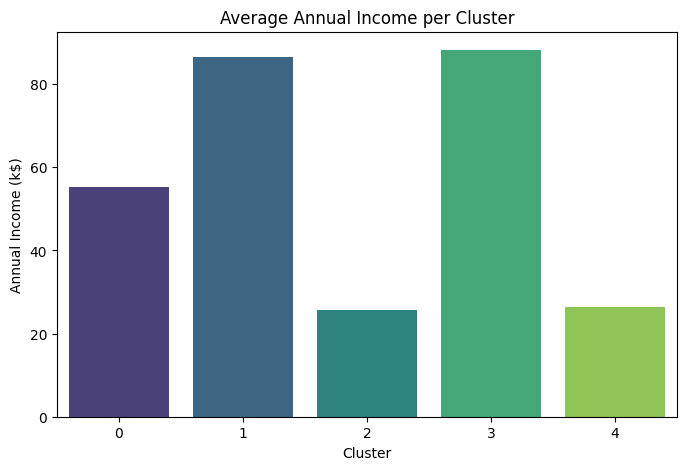

/tmp/ipython-input-1219658804.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cluster', y='Spending Score (1-100)', data=cluster_summary, palette="plasma")


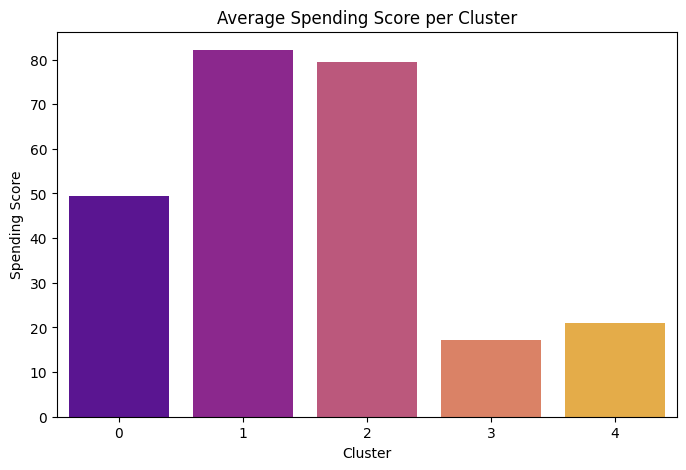

In [7]:
import seaborn as sns

# Cluster Summary (mean values for each cluster)
cluster_summary = data.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean().reset_index()
print(cluster_summary)

# Bar plot for Annual Income
plt.figure(figsize=(8,5))
sns.barplot(x='Cluster', y='Annual Income (k$)', data=cluster_summary, palette="viridis")
plt.title("Average Annual Income per Cluster")
plt.ylabel("Annual Income (k$)")
plt.xlabel("Cluster")
plt.show()

# Bar plot for Spending Score
plt.figure(figsize=(8,5))
sns.barplot(x='Cluster', y='Spending Score (1-100)', data=cluster_summary, palette="plasma")
plt.title("Average Spending Score per Cluster")
plt.ylabel("Spending Score")
plt.xlabel("Cluster")
plt.show()
